# Supplementary Figure S5: Robustness to perturbations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/representation_analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
figure_name = "FigS5_robustness_to_perturbations"
model_list = ["vanBP", "bpDale_fixed", "HebbWN_topsup", "bpLike_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None)

Generating plots for Backprop (ANN)


/var/folders/q9/g15z8pxs2fd8tgyd9ggfv1c8x5w4qx/T/ipykernel_68831/1631154955.py:46: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)
/var/folders/q9/g15z8pxs2fd8tgyd9ggfv1c8x5w4qx/T/ipykernel_68831/1631154955.py:56: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(bottom=0)


Generating plots for Backprop (EIANN)
Generating plots for Hebb (EIANN)
Generating plots for Dend. Target Prop.


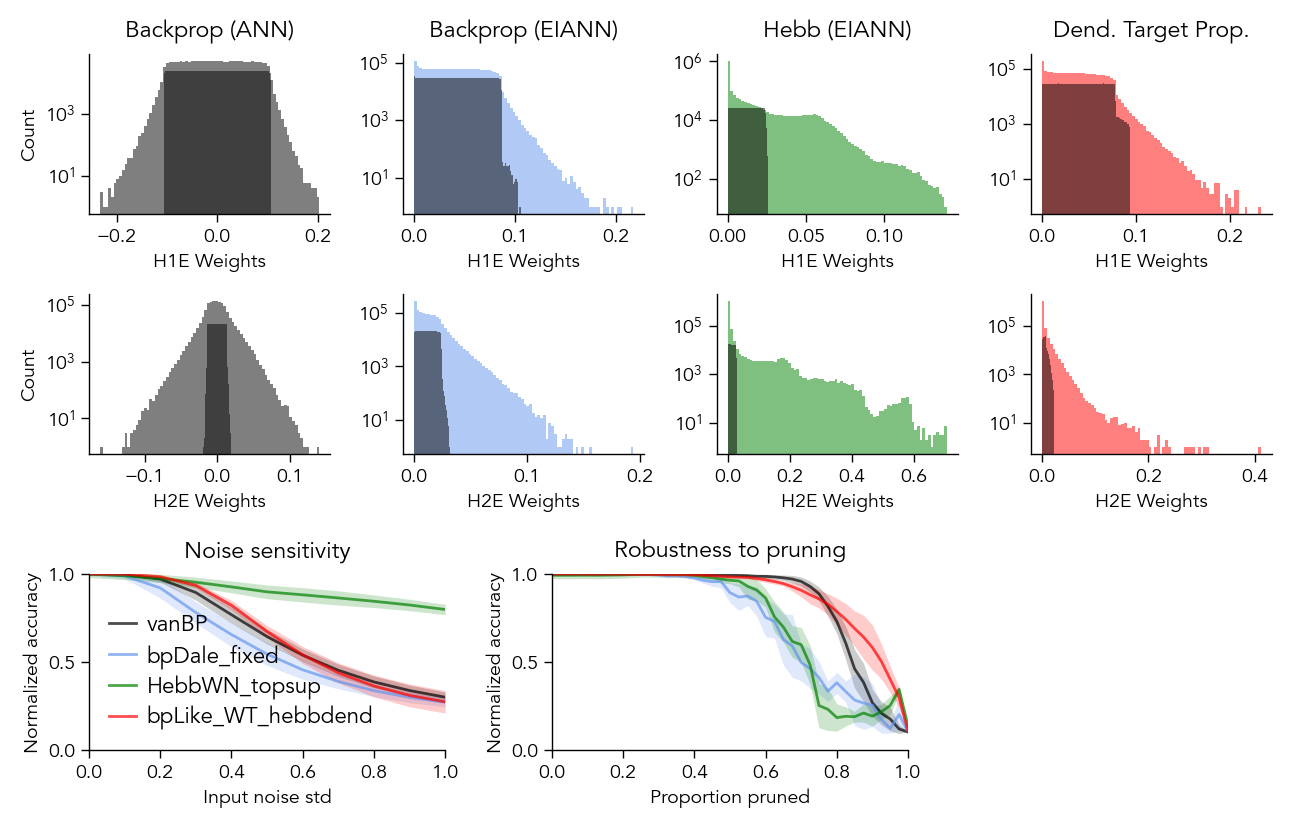

In [31]:
fig = plt.figure(figsize=(6.5, 4))
axes = gs.GridSpec(nrows=2, ncols=4, figure=fig,                    
                    left=0.07,right=0.98,
                    top=0.95, bottom=0.45,
                    wspace=0.3, hspace=0.5)

axes_perturbations = gs.GridSpec(nrows=1, ncols=2, figure=fig,                    
                    left=0.07,right=0.7,
                    top=0.3, bottom=0.08,
                    wspace=0.3, hspace=0.5)
ax_noise = fig.add_subplot(axes_perturbations[0, 0])
ax_pruning = fig.add_subplot(axes_perturbations[0, 1])

model_dict_all["vanBP"]["display_name"] = "Feedforward ANN \n Backprop"
model_dict_all["bpLike_WT_hebbdend"]["display_name"] = "Dendritic Target \nPropagation (LDS)"
model_dict_all["bpDale_fixed"]["display_name"] = "EIANN \n Backprop"
model_dict_all["HebbWN_topsup"]["display_name"] = "EIANN \n Hebb + Weight Norm."

for col, model_key in enumerate(model_list):
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")

        #########################
        # Weight distributions
        #########################
        H1E_weights = {'initial': [], 'final': []}
        H2E_weights = {'initial': [], 'final': []}
        for seed in model_dict['seeds']:
            H1E_weights['initial'].extend(data_dict[seed]['weights']['initial_weights']['H1E_InputE'][:].flatten())
            H2E_weights['initial'].extend(data_dict[seed]['weights']['initial_weights']['H2E_H1E'][:].flatten())
            H1E_weights['final'].extend(data_dict[seed]['weights']['final_weights']['H1E_InputE'][:].flatten())
            H2E_weights['final'].extend(data_dict[seed]['weights']['final_weights']['H2E_H1E'][:].flatten())

        ax = fig.add_subplot(axes[0, col])
        ax.hist(H1E_weights['final'], bins=80, alpha=0.5, color=model_dict["color"], density=False)
        ax.hist(H1E_weights['initial'], bins=80, alpha=0.5, label='Initial', color='k', density=False)
        ax.set_xlabel("H1E Weights")
        if col == 0:
            ax.set_ylabel("Count")
        ax.set_title(model_dict['label'])
        ax.set_yscale('log')
        ax.set_ylim(bottom=0)
        # ax.legend(frameon=False, fontsize=8, loc='upper right')

        ax = fig.add_subplot(axes[1, col])
        ax.hist(H2E_weights['final'], bins=80, alpha=0.5, color=model_dict["color"], density=False)
        ax.hist(H2E_weights['initial'], bins=80, alpha=0.5, label='Initial', color='k', density=False)
        ax.set_xlabel("H2E Weights")
        if col == 0:
            ax.set_ylabel("Count")
        ax.set_yscale('log')
        ax.set_ylim(bottom=0)
        # ax.legend(frameon=False, fontsize=8, loc='upper right')

        ###############################
        # Robustness to input noise
        ###############################
        accuracy_list = []
        for seed in model_dict['seeds']:
            noise_stds, noise_accuracy = data_dict[seed]['noise_sensitivity']
            accuracy_list.append(noise_accuracy)
        accuracy_array = np.array(accuracy_list)
        mean_accuracy = np.mean(accuracy_array, axis=0)
        mean_accuracy_norm = mean_accuracy / np.max(mean_accuracy)
        std_accuracy_norm = np.std(accuracy_array, axis=0) / np.max(mean_accuracy)
        ax_noise.plot(noise_stds, mean_accuracy_norm, label=model_key, linewidth=1, color=model_dict["color"], alpha=0.7)
        ax_noise.fill_between(noise_stds, mean_accuracy_norm - std_accuracy_norm, mean_accuracy_norm + std_accuracy_norm, alpha=0.2, color=model_dict["color"], linewidth=0.) 
        ax_noise.set_xlabel("Input noise std")
        ax_noise.set_ylabel("Normalized accuracy")
        ax_noise.set_title("Noise sensitivity")
        ax_noise.set_xlim([0, 1])
        ax_noise.set_ylim([0, 1])
        ax_noise.set_yticks([0, 0.5, 1])
        ax_noise.legend(frameon=False, fontsize=8, loc='lower left')

        ##################################
        # Robustness to synaptic pruning
        ##################################
        accuracy_list = []
        for seed in model_dict['seeds']:
            fraction_to_prune, accuracy = data_dict[seed]['robustness_to_pruning_all']
            accuracy_list.append(accuracy)
        accuracy_array = np.array(accuracy_list)
        mean_accuracy = np.mean(accuracy_array, axis=0)
        mean_accuracy_norm = mean_accuracy / np.max(mean_accuracy)
        std_accuracy_norm = np.std(accuracy_array, axis=0) / np.max(mean_accuracy)
        ax_pruning.plot(fraction_to_prune, mean_accuracy_norm, label=model_key, linewidth=1, color=model_dict["color"], alpha=0.7)
        ax_pruning.fill_between(fraction_to_prune, mean_accuracy_norm - std_accuracy_norm, mean_accuracy_norm + std_accuracy_norm, alpha=0.2, color=model_dict["color"], linewidth=0.) 
        ax_pruning.set_xlabel("Proportion pruned")
        ax_pruning.set_ylabel("Normalized accuracy")
        ax_pruning.set_title("Robustness to pruning")
        ax_pruning.set_xlim([0, 1])
        ax_pruning.set_ylim([0, 1])
        ax_pruning.set_yticks([0, 0.5, 1])
plt.show(block=False)

fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)